In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import cartopy.io.shapereader as shpreader
import matplotlib.colors as colors

In [2]:
def get_naq_season(mon1,mon2,mon3):
    df1 = np.fromfile(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML NAQ 数据\testd1.2018{}.grd'.format(mon1),dtype='>f4')
    conc_1 = df1.reshape(20,180,360)
    df2 = np.fromfile(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML NAQ 数据\testd1.2018{}.grd'.format(mon2),dtype='>f4')
    conc_2 = df2.reshape(20,180,360)
    df3 = np.fromfile(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML NAQ 数据\testd1.2018{}.grd'.format(mon3),dtype='>f4')
    conc_3 = df3.reshape(20,180,360)
    conc_season = (conc_1+conc_2+conc_3)/3
    return conc_season

In [3]:
conc_spring = get_naq_season('03','04','05')
conc_summer = get_naq_season('06','07','08')
conc_autumn = get_naq_season('09','10','11')
conc_winter = get_naq_season('12','01','02')

In [4]:
conc_year = (conc_spring+conc_summer+conc_autumn+conc_winter)/4

In [5]:
lat = np.array(range(-90,90,1))+0.5
lon = np.array(range(0,360,1))+0.5

In [6]:
gml_out_obspack = ['ALT', 'ICE', 'KUM', 'MHD', 'NMB', 'PSA', 'TAP', 'USH', 'UTA','UUM',\
                   'WIS']

In [7]:
obs_names = ['ALT','ASC','ASK','AZR','BHD','BKT','BMW','BRW','CBA','CGO',\
             'CHR','CRZ','EIC','GMI','HUN','ICE','IZO','KEY','KUM','LEF',\
             'MHD','MID','MLO','NMB','NWR','PAL','PSA','RPB','SEY','SGP',\
             'SHM','SMO','SPO','SUM','SYO','TAP','USH','UTA','UUM','WIS',\
             'WLG','ZEP' ]

In [8]:
gml_in_obspack = [station for station in obs_names if station not in gml_out_obspack]

In [10]:
def get_obs(obs_name):
    df = pd.read_csv(f'D:/workdata/25/global_monmean_obs_co2/txt.{obs_name}',header=None,sep=' ')
    data = df.values
    data = data[-12:,2]
    return data

In [11]:
obs_data_1 = np.zeros((12,31))
for ii in range(31):
    obs_name = gml_in_obspack[ii]
    obs_data_1[:,ii] = get_obs(obs_name)

In [12]:
obs_data_2 = np.zeros((12,11))
for ii in range(11):
    obs_name_ab = gml_out_obspack[ii]
    obs_data_2[:,ii] = get_obs(obs_name_ab)

In [14]:
# 位于模式第一层的观测站点数据预处理
obs_1 = {
    'Name': gml_in_obspack
}

# 创建DataFrame
df_obs1 = pd.DataFrame(obs_1)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month in months:
    df_obs1[month] = None

# 假设这是你的np.array数据，shape为(12, 27)
arr = obs_data_1  # 示例数据，实际应该是你的数据

# 给DataFrame中对应的月份列赋值
for i, month in enumerate(months):
    df_obs1[month] = arr[i]

df_obs1['Spring'] = ((df_obs1['Mar'].values+df_obs1['Apr'].values+df_obs1['May'].values)/3)
df_obs1['Summer'] = ((df_obs1['Jun'].values+df_obs1['Jul'].values+df_obs1['Aug'].values)/3)
df_obs1['Autumn'] = ((df_obs1['Sep'].values+df_obs1['Oct'].values+df_obs1['Nov'].values)/3)
df_obs1['Winter'] = ((df_obs1['Dec'].values+df_obs1['Jan'].values+df_obs1['Feb'].values)/3)


In [15]:
# 位于模式第一层的观测站点数据预处理
obs_2 = {
    'Name': gml_out_obspack
}

# 创建DataFrame
df_obs2 = pd.DataFrame(obs_2)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month in months:
    df_obs2[month] = None

# 假设这是你的np.array数据，shape为(12, 27)
arr2 = obs_data_2  # 示例数据，实际应该是你的数据

# 给DataFrame中对应的月份列赋值
for i, month in enumerate(months):
    df_obs2[month] = arr2[i]

df_obs2['Spring'] = ((df_obs2['Mar'].values+df_obs2['Apr'].values+df_obs2['May'].values)/3)
df_obs2['Summer'] = ((df_obs2['Jun'].values+df_obs2['Jul'].values+df_obs2['Aug'].values)/3)
df_obs2['Autumn'] = ((df_obs2['Sep'].values+df_obs2['Oct'].values+df_obs2['Nov'].values)/3)
df_obs2['Winter'] = ((df_obs2['Dec'].values+df_obs2['Jan'].values+df_obs2['Feb'].values)/3)


In [16]:
station_info = pd.read_csv(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML 站点选取\sta.paper.csv')

In [17]:
# 确保两列数据的大小写和空格一致 统一格式很重要！！！！！
df_obs1['Name'] = df_obs1['Name'].str.strip().str.upper()  # 去除空格并转为大写
station_info['station'] = station_info['station'].str.strip().str.upper()  # 去除空格并转为大写

# 重新筛选数据
filtered_station_info = station_info[station_info['station'].isin(df_obs1['Name'])]
df_obs1['Latitude'] = filtered_station_info['Latitude'].values
df_obs1['Longitude'] = filtered_station_info['Longitude'].values

In [18]:
# 确保两列数据的大小写和空格一致 统一格式很重要！！！！！
df_obs2['Name'] = df_obs2['Name'].str.strip().str.upper()  # 去除空格并转为大写
station_info['station'] = station_info['station'].str.strip().str.upper()  # 去除空格并转为大写

# 重新筛选数据
filtered_station_info = station_info[station_info['station'].isin(df_obs2['Name'])]
df_obs2['Latitude'] = filtered_station_info['Latitude'].values
df_obs2['Longitude'] = filtered_station_info['Longitude'].values

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\1368723396.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pcm = fig_ax1.pcolormesh(lon,lat,conc_spring[0,:,:]/1000, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=400, vmax=420)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\1368723396.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\1368723396.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[n

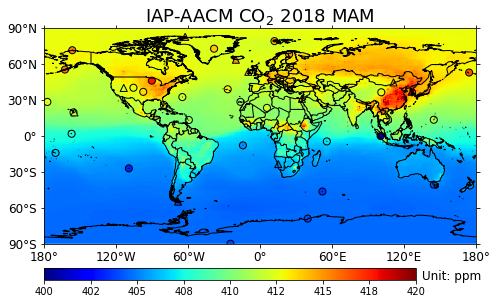

In [20]:
season = 'Spring'


proj = ccrs.PlateCarree(central_longitude=0)
#创建图形
fig = plt.figure(figsize=(12, 8))
fig_ax1 = fig.add_axes([0.25, 0.25, 0.5, 0.5],projection = proj)
#设置边界
leftlon, rightlon, lowerlat, upperlat = (-180,180,-90,90)
img_extent = [leftlon, rightlon, lowerlat, upperlat]
fig_ax1.set_extent(img_extent, crs=ccrs.PlateCarree())
#绘制海岸线和湖泊等地理特征
fig_ax1.add_feature(cfeature.COASTLINE.with_scale('50m'))
fig_ax1.add_feature(cfeature.BORDERS.with_scale('50m'))
#设置刻度及刻度标签格式
plt.tick_params(top='on', right='on', which='both')#显示轴刻度
fig_ax1.set_xticks(np.arange(leftlon,rightlon+60,60), crs=ccrs.PlateCarree())
fig_ax1.set_yticks(np.arange(lowerlat,upperlat+30,30), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
lat_formatter = cticker.LatitudeFormatter()
fig_ax1.xaxis.set_major_formatter(lon_formatter)
fig_ax1.yaxis.set_major_formatter(lat_formatter)
#由于0°空白，增加绘图序列，补全0°空白
from cartopy.util import add_cyclic_point

pcm = fig_ax1.pcolormesh(lon,lat,conc_spring[0,:,:]/1000, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=400, vmax=420)

# 在pcolormesh绘图后添加以下代码
scatter_point = fig_ax1.scatter(
    df_obs1['Longitude'].values, df_obs1['Latitude'].values,                   # 经纬度坐标
    c=df_obs1['Spring'].values,                     # 数值对应颜色
    cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
    vmin=400, vmax=420,        # 保持与背景相同的范围
    edgecolors='black',          # 红色边框突出显示
    linewidths=1,              # 边框粗细
    s=50,                      # 点的大小 
    zorder=1,                  # 确保点在图层上方
    transform=ccrs.PlateCarree()
)

# 在pcolormesh绘图后添加以下代码
scatter_point = fig_ax1.scatter(
    df_obs2['Longitude'].values, df_obs2['Latitude'].values,                   # 经纬度坐标
    c=df_obs2['Spring'].values,                     # 数值对应颜色
    cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
    vmin=400, vmax=420,        # 保持与背景相同的范围
    edgecolors='black',          # 红色边框突出显示
    linewidths=1,              # 边框粗细
    s=50,                      # 点的大小 
    zorder=1,                  # 确保点在图层上方
    transform=ccrs.PlateCarree(),
    marker='^' 
)


position=fig.add_axes([0.25, 0.25, 0.43, 0.02])
cb = fig.colorbar(pcm,cax=position,orientation='horizontal',format='%.0f',)
fig_ax1.text(135,-120,'Unit: ppm',fontsize=12)
fig_ax1.tick_params(axis='both', labelsize=12)
fig_ax1.set_title(f'IAP-AACM CO$_2$ 2018 MAM',loc='center',fontsize =18)


plt.rcParams['savefig.dpi'] = 500 
plt.savefig(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML NAQ 数据\iapaacm_spring.r4.png',bbox_inches='tight')

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\1877576695.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pcm = fig_ax1.pcolormesh(lon,lat,conc_summer[0,:,:]/1000, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=400, vmax=420)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\1877576695.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\1877576695.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[n

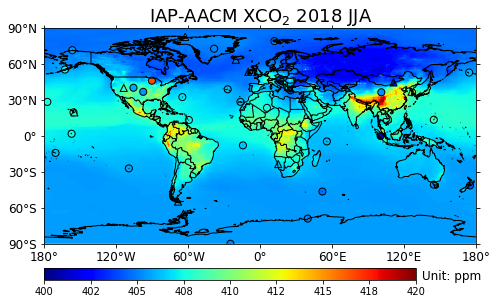

In [21]:
season = 'Summer'


proj = ccrs.PlateCarree(central_longitude=0)
#创建图形
fig = plt.figure(figsize=(12, 8))
fig_ax1 = fig.add_axes([0.25, 0.25, 0.5, 0.5],projection = proj)
#设置边界
leftlon, rightlon, lowerlat, upperlat = (-180,180,-90,90)
img_extent = [leftlon, rightlon, lowerlat, upperlat]
fig_ax1.set_extent(img_extent, crs=ccrs.PlateCarree())
#绘制海岸线和湖泊等地理特征
fig_ax1.add_feature(cfeature.COASTLINE.with_scale('50m'))
fig_ax1.add_feature(cfeature.BORDERS.with_scale('50m'))
#设置刻度及刻度标签格式
plt.tick_params(top='on', right='on', which='both')#显示轴刻度
fig_ax1.set_xticks(np.arange(leftlon,rightlon+60,60), crs=ccrs.PlateCarree())
fig_ax1.set_yticks(np.arange(lowerlat,upperlat+30,30), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
lat_formatter = cticker.LatitudeFormatter()
fig_ax1.xaxis.set_major_formatter(lon_formatter)
fig_ax1.yaxis.set_major_formatter(lat_formatter)
#由于0°空白，增加绘图序列，补全0°空白
from cartopy.util import add_cyclic_point

pcm = fig_ax1.pcolormesh(lon,lat,conc_summer[0,:,:]/1000, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=400, vmax=420)

# 在pcolormesh绘图后添加以下代码
scatter_point = fig_ax1.scatter(
    df_obs1['Longitude'].values, df_obs1['Latitude'].values,                   # 经纬度坐标
    c=df_obs1['Summer'].values,                     # 数值对应颜色
    cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
    vmin=400, vmax=420,        # 保持与背景相同的范围
    edgecolors='black',          # 红色边框突出显示
    linewidths=1,              # 边框粗细
    s=50,                      # 点的大小 
    zorder=1,                  # 确保点在图层上方
    transform=ccrs.PlateCarree()
)

scatter_point = fig_ax1.scatter(
    df_obs2['Longitude'].values, df_obs2['Latitude'].values,                   # 经纬度坐标
    c=df_obs2['Summer'].values,                     # 数值对应颜色
    cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
    vmin=400, vmax=420,        # 保持与背景相同的范围
    edgecolors='black',          # 红色边框突出显示
    linewidths=1,              # 边框粗细
    s=50,                      # 点的大小 
    zorder=1,                  # 确保点在图层上方
    transform=ccrs.PlateCarree(),
    marker='^' 
)

position=fig.add_axes([0.25, 0.25, 0.43, 0.02])
cb = fig.colorbar(pcm,cax=position,orientation='horizontal',format='%.0f',)
fig_ax1.text(135,-120,'Unit: ppm',fontsize=12)
fig_ax1.tick_params(axis='both', labelsize=12)
fig_ax1.set_title(f'IAP-AACM XCO$_2$ 2018 JJA',loc='center',fontsize =18)


plt.rcParams['savefig.dpi'] = 500 
plt.savefig(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML NAQ 数据\iapaacm_summer.r4.png',bbox_inches='tight')

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\2573036549.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pcm = fig_ax1.pcolormesh(lon,lat,conc_autumn[0,:,:]/1000, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=400, vmax=420)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\2573036549.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\2573036549.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[n

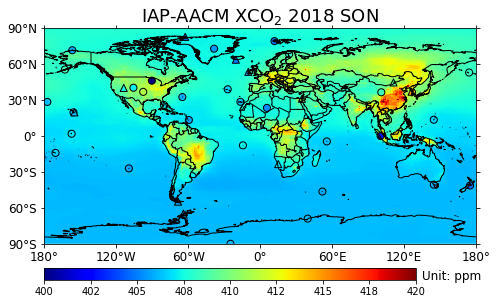

In [22]:
season = 'Autumn'


proj = ccrs.PlateCarree(central_longitude=0)
#创建图形
fig = plt.figure(figsize=(12, 8))
fig_ax1 = fig.add_axes([0.25, 0.25, 0.5, 0.5],projection = proj)
#设置边界
leftlon, rightlon, lowerlat, upperlat = (-180,180,-90,90)
img_extent = [leftlon, rightlon, lowerlat, upperlat]
fig_ax1.set_extent(img_extent, crs=ccrs.PlateCarree())
#绘制海岸线和湖泊等地理特征
fig_ax1.add_feature(cfeature.COASTLINE.with_scale('50m'))
fig_ax1.add_feature(cfeature.BORDERS.with_scale('50m'))
#设置刻度及刻度标签格式
plt.tick_params(top='on', right='on', which='both')#显示轴刻度
fig_ax1.set_xticks(np.arange(leftlon,rightlon+60,60), crs=ccrs.PlateCarree())
fig_ax1.set_yticks(np.arange(lowerlat,upperlat+30,30), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
lat_formatter = cticker.LatitudeFormatter()
fig_ax1.xaxis.set_major_formatter(lon_formatter)
fig_ax1.yaxis.set_major_formatter(lat_formatter)
#由于0°空白，增加绘图序列，补全0°空白
from cartopy.util import add_cyclic_point

pcm = fig_ax1.pcolormesh(lon,lat,conc_autumn[0,:,:]/1000, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=400, vmax=420)

# 在pcolormesh绘图后添加以下代码
scatter_point = fig_ax1.scatter(
    df_obs1['Longitude'].values, df_obs1['Latitude'].values,                   # 经纬度坐标
    c=df_obs1['Autumn'].values,                     # 数值对应颜色
    cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
    vmin=400, vmax=420,        # 保持与背景相同的范围
    edgecolors='black',          # 红色边框突出显示
    linewidths=1,              # 边框粗细
    s=50,                      # 点的大小 
    zorder=1,                  # 确保点在图层上方
    transform=ccrs.PlateCarree()
)

scatter_point = fig_ax1.scatter(
    df_obs2['Longitude'].values, df_obs2['Latitude'].values,                   # 经纬度坐标
    c=df_obs2['Autumn'].values,                     # 数值对应颜色
    cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
    vmin=400, vmax=420,        # 保持与背景相同的范围
    edgecolors='black',          # 红色边框突出显示
    linewidths=1,              # 边框粗细
    s=50,                      # 点的大小 
    zorder=1,                  # 确保点在图层上方
    transform=ccrs.PlateCarree(),
    marker='^' 
)

position=fig.add_axes([0.25, 0.25, 0.43, 0.02])
cb = fig.colorbar(pcm,cax=position,orientation='horizontal',format='%.0f',)
fig_ax1.text(135,-120,'Unit: ppm',fontsize=12)
fig_ax1.tick_params(axis='both', labelsize=12)
fig_ax1.set_title(f'IAP-AACM XCO$_2$ 2018 SON',loc='center',fontsize =18)


plt.rcParams['savefig.dpi'] = 500 
plt.savefig(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML NAQ 数据\iapaacm_autumn.r4.png',bbox_inches='tight')

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\3809438081.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pcm = fig_ax1.pcolormesh(lon,lat,conc_winter[0,:,:]/1000, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=400, vmax=420)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\3809438081.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\3809438081.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[n

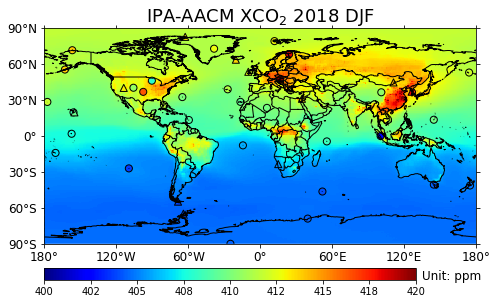

In [23]:
season = 'Winter'


proj = ccrs.PlateCarree(central_longitude=0)
#创建图形
fig = plt.figure(figsize=(12, 8))
fig_ax1 = fig.add_axes([0.25, 0.25, 0.5, 0.5],projection = proj)
#设置边界
leftlon, rightlon, lowerlat, upperlat = (-180,180,-90,90)
img_extent = [leftlon, rightlon, lowerlat, upperlat]
fig_ax1.set_extent(img_extent, crs=ccrs.PlateCarree())
#绘制海岸线和湖泊等地理特征
fig_ax1.add_feature(cfeature.COASTLINE.with_scale('50m'))
fig_ax1.add_feature(cfeature.BORDERS.with_scale('50m'))
#设置刻度及刻度标签格式
plt.tick_params(top='on', right='on', which='both')#显示轴刻度
fig_ax1.set_xticks(np.arange(leftlon,rightlon+60,60), crs=ccrs.PlateCarree())
fig_ax1.set_yticks(np.arange(lowerlat,upperlat+30,30), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
lat_formatter = cticker.LatitudeFormatter()
fig_ax1.xaxis.set_major_formatter(lon_formatter)
fig_ax1.yaxis.set_major_formatter(lat_formatter)
#由于0°空白，增加绘图序列，补全0°空白
from cartopy.util import add_cyclic_point

pcm = fig_ax1.pcolormesh(lon,lat,conc_winter[0,:,:]/1000, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=400, vmax=420)

# 在pcolormesh绘图后添加以下代码
scatter_point = fig_ax1.scatter(
    df_obs1['Longitude'].values, df_obs1['Latitude'].values,                   # 经纬度坐标
    c=df_obs1['Winter'].values,                     # 数值对应颜色
    cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
    vmin=400, vmax=420,        # 保持与背景相同的范围
    edgecolors='black',          # 红色边框突出显示
    linewidths=1,              # 边框粗细
    s=50,                      # 点的大小 
    zorder=1,                  # 确保点在图层上方
    transform=ccrs.PlateCarree()
)

scatter_point = fig_ax1.scatter(
    df_obs2['Longitude'].values, df_obs2['Latitude'].values,                   # 经纬度坐标
    c=df_obs2['Winter'].values,                     # 数值对应颜色
    cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
    vmin=400, vmax=420,        # 保持与背景相同的范围
    edgecolors='black',          # 红色边框突出显示
    linewidths=1,              # 边框粗细
    s=50,                      # 点的大小 
    zorder=1,                  # 确保点在图层上方
    transform=ccrs.PlateCarree(),
    marker='^' 
)

position=fig.add_axes([0.25, 0.25, 0.43, 0.02])
cb = fig.colorbar(pcm,cax=position,orientation='horizontal',format='%.0f',)
fig_ax1.text(135,-120,'Unit: ppm',fontsize=12)

fig_ax1.set_title(f'IPA-AACM XCO$_2$ 2018 DJF',loc='center',fontsize =18)
fig_ax1.tick_params(axis='both', labelsize=12)

plt.rcParams['savefig.dpi'] = 500 
plt.savefig(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML NAQ 数据\iapaacm_winter.r4.png',bbox_inches='tight')

In [24]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from adjustText import adjust_text  # 动态调整标注位置

# 站点列表（需要绘制为蓝色圆圈）
gml_out_obspack = ['ALT', 'ICE', 'KUM', 'MHD', 'NMB', 'PSA', 'TAP', 'USH', 'UTA', 'UUM', \
                   'WIS']

# 加载站点数据
station_data = pd.read_csv(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML\filtered_station_data.csv')  

# 分离两类站点
in_stations = station_data[station_data['Station'].str.strip().isin(gml_out_obspack)]
out_stations = station_data[~station_data['Station'].str.strip().isin(gml_out_obspack)]


C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\3216248886.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pcm = fig_ax1.pcolormesh(lon,lat,conc_year[0,:,:]/1000, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=400, vmax=420)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\3216248886.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_32188\3216248886.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[nam

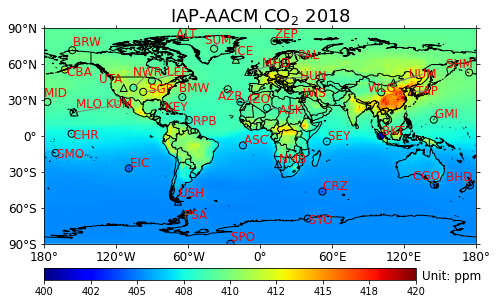

In [25]:
season = '2018'


proj = ccrs.PlateCarree(central_longitude=0)
#创建图形
fig = plt.figure(figsize=(12, 8))
fig_ax1 = fig.add_axes([0.25, 0.25, 0.5, 0.5],projection = proj)
#设置边界
leftlon, rightlon, lowerlat, upperlat = (-180,180,-90,90)
img_extent = [leftlon, rightlon, lowerlat, upperlat]
fig_ax1.set_extent(img_extent, crs=ccrs.PlateCarree())
#绘制海岸线和湖泊等地理特征
fig_ax1.add_feature(cfeature.COASTLINE.with_scale('50m'))
fig_ax1.add_feature(cfeature.BORDERS.with_scale('50m'))
#设置刻度及刻度标签格式
plt.tick_params(top='on', right='on', which='both')#显示轴刻度
fig_ax1.set_xticks(np.arange(leftlon,rightlon+60,60), crs=ccrs.PlateCarree())
fig_ax1.set_yticks(np.arange(lowerlat,upperlat+30,30), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
lat_formatter = cticker.LatitudeFormatter()
fig_ax1.xaxis.set_major_formatter(lon_formatter)
fig_ax1.yaxis.set_major_formatter(lat_formatter)
#由于0°空白，增加绘图序列，补全0°空白
from cartopy.util import add_cyclic_point

pcm = fig_ax1.pcolormesh(lon,lat,conc_year[0,:,:]/1000, zorder=0,transform=ccrs.PlateCarree(),cmap = plt.cm.get_cmap('jet'),vmin=400, vmax=420)

# 在pcolormesh绘图后添加以下代码
scatter_point = fig_ax1.scatter(
    df_obs1['Longitude'].values, df_obs1['Latitude'].values,                   # 经纬度坐标
    c=(df_obs1['Spring'].values+df_obs1['Summer'].values+df_obs1['Autumn'].values+df_obs1['Winter'].values)/4,                     # 数值对应颜色
    cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
    vmin=400, vmax=420,        # 保持与背景相同的范围
    edgecolors='black',          # 红色边框突出显示
    linewidths=1,              # 边框粗细
    s=50,                      # 点的大小 
    zorder=1,                  # 确保点在图层上方
    transform=ccrs.PlateCarree()
)

# 在pcolormesh绘图后添加以下代码
scatter_point = fig_ax1.scatter(
    df_obs2['Longitude'].values, df_obs2['Latitude'].values,                   # 经纬度坐标
    c=(df_obs2['Spring'].values+df_obs2['Summer'].values+df_obs2['Autumn'].values+df_obs2['Winter'].values)/4,                     # 数值对应颜色
    cmap=plt.cm.get_cmap('jet'), # 使用与背景相同的colormap
    vmin=400, vmax=420,        # 保持与背景相同的范围
    edgecolors='black',          # 红色边框突出显示
    linewidths=1,              # 边框粗细
    s=50,                      # 点的大小 
    zorder=1,                  # 确保点在图层上方
    transform=ccrs.PlateCarree(),
    marker='^' 
)

# 添加站点标签
new_texts = [
    plt.text(x_, y_, text, fontsize=12, color='red' if text in gml_out_obspack else 'red',
             )
    for x_, y_, text in zip(station_data['Longitude'], station_data['Latitude'], station_data['Station'])
]


# 调整标签位置
adjust_text(new_texts, 
            expand_text=(1.2, 1.8),
            only_move={'text': 'x'},
            arrowprops=dict(arrowstyle='-', color='grey'),
            save_steps=True)

position=fig.add_axes([0.25, 0.25, 0.43, 0.02])
cb = fig.colorbar(pcm,cax=position,orientation='horizontal',format='%.0f',)
fig_ax1.text(135,-120,'Unit: ppm',fontsize=12)
fig_ax1.set_title(f'IAP-AACM CO$_2$ {season}',loc='center',fontsize =18)
fig_ax1.tick_params(axis='both', labelsize=12)

plt.rcParams['savefig.dpi'] = 500 
plt.savefig(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\NOAA GML NAQ 数据\iapaacm_2018.r4.png',bbox_inches='tight')